In [2]:
import pandas as pd

In [3]:
data=pd.read_csv("/Users/rhythamsuri/Downloads/Bank Customer Churn Prediction.csv")

In [4]:
data=data.copy()

In [5]:
data

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
data.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [7]:
data.tail()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,15628319,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [9]:
import seaborn as sns

In [10]:
import matplotlib.pyplot as plt

<Axes: xlabel='estimated_salary', ylabel='Density'>

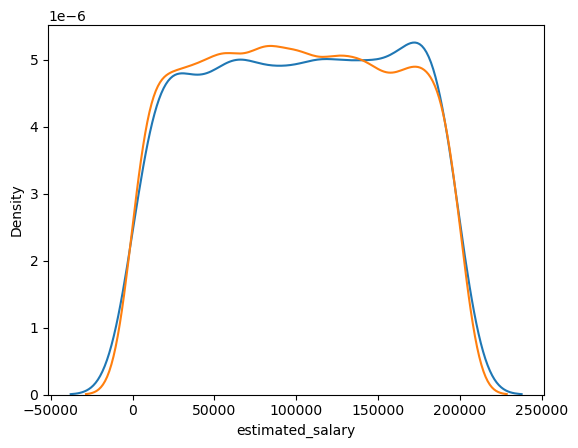

In [20]:
# The salary between the churn and non-churn customers is the same, so this is the reason 
#we cannot add it to analysis 
sns.kdeplot(churn['estimated_salary'])
sns.kdeplot(stay['estimated_salary'])

In [22]:
#counting how many customers each country has.
country_count = data.groupby('country')['customer_id'].count()
print(country_count)

country
France     5014
Germany    2509
Spain      2477
Name: customer_id, dtype: int64


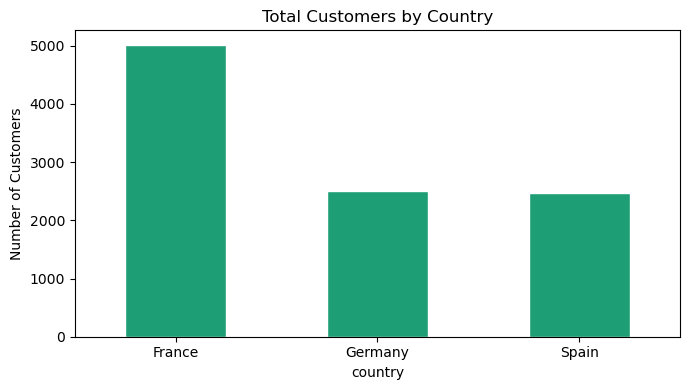

In [23]:
# Dropping 'customer_id' because it is just a unique number assigned to each
# customer by the bank. It has no relationship with churn behaviour.
# If kept, the model may memorize these IDs and overfit on training data.

country_count.plot(kind='bar', color='#1D9E75', edgecolor='white', figsize=(7,4))
plt.title('Total Customers by Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


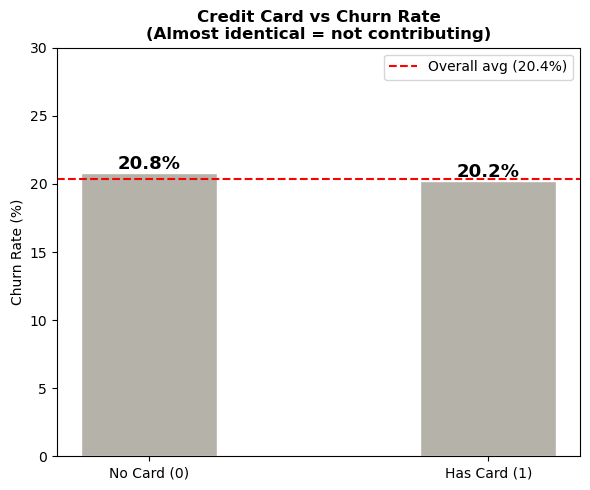

In [27]:
#In the figure it clearly seen that customers who have card and who does not have
#card has no impact on churn rate and cannot be used for analysis.
cc_churn = data.groupby('credit_card')['churn'].mean() * 100

plt.figure(figsize=(6, 5))
plt.bar(['No Card (0)', 'Has Card (1)'],
        cc_churn.values,
        color=['#B4B2A9', '#B4B2A9'],  # gray = not significant
        edgecolor='white', width=0.4)

# Adding value labels on top of each bar
for i, v in enumerate(cc_churn.values):
    plt.text(i, v + 0.3, f'{v:.1f}%',
             ha='center', fontweight='bold', fontsize=13)

# Overall average line for reference
plt.axhline(data['churn'].mean() * 100,
            color='red', linestyle='--', linewidth=1.5,
            label=f'Overall avg ({data["churn"].mean()*100:.1f}%)')

plt.title('Credit Card vs Churn Rate\n(Almost identical = not contributing)',
          fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 30)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [30]:
#now we are dropping the columns {customer_id,estimated_salary,credit_card}
data=data.drop(['customer_id','estimated_salary','credit_card'],axis=1)

In [31]:
data

,credit_score,country,gender,age,tenure,balance,products_number,active_member,churn
0,619,France,Female,42,2,0.00,1,1,1
1,608,Spain,Female,41,1,83807.86,1,1,0
2,502,France,Female,42,8,159660.80,3,0,1
3,699,France,Female,39,1,0.00,2,0,0
4,850,Spain,Female,43,2,125510.82,1,1,0
...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,0,0
9996,516,France,Male,35,10,57369.61,1,1,0
9997,709,France,Female,36,7,0.00,1,1,1
9998,772,Germany,Male,42,3,75075.31,2,0,1


In [32]:
#checking datatype and null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   credit_score     10000 non-null  int64  
 1   country          10000 non-null  object 
 2   gender           10000 non-null  object 
 3   age              10000 non-null  int64  
 4   tenure           10000 non-null  int64  
 5   balance          10000 non-null  float64
 6   products_number  10000 non-null  int64  
 7   active_member    10000 non-null  int64  
 8   churn            10000 non-null  int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 703.3+ KB


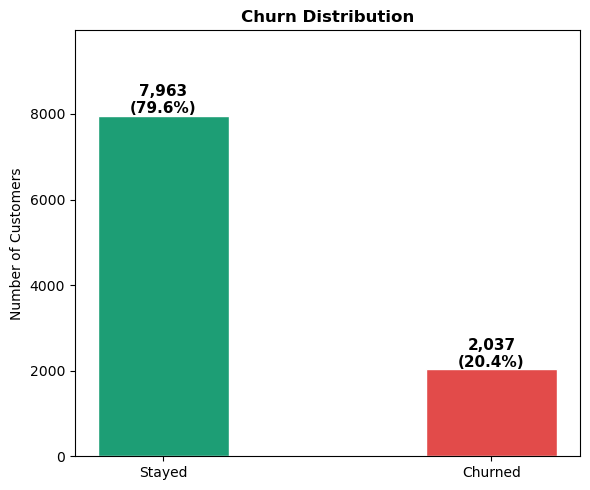

In [33]:
# The churn customers were 2,037, and who stayed were 7,963
#the reason behind this figure is to get a clear picture how many 
#customers we have with and leaving all across our 3 branches.

churn_counts = data['churn'].value_counts()

plt.figure(figsize=(6, 5))

bars = plt.bar(
    ['Stayed', 'Churned'],
    churn_counts.values,
    color=['#1D9E75', '#E24B4A'],
    edgecolor='white',
    width=0.4
)

# Adding count + percentage on top of each bar
for bar, val in zip(bars, churn_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{val:,}\n({val/len(data)*100:.1f}%)',
        ha='center', fontweight='bold', fontsize=11
    )

plt.title('Churn Distribution', fontweight='bold')
plt.ylabel('Number of Customers')
plt.ylim(0, max(churn_counts.values) * 1.25)
plt.tight_layout()
plt.show()

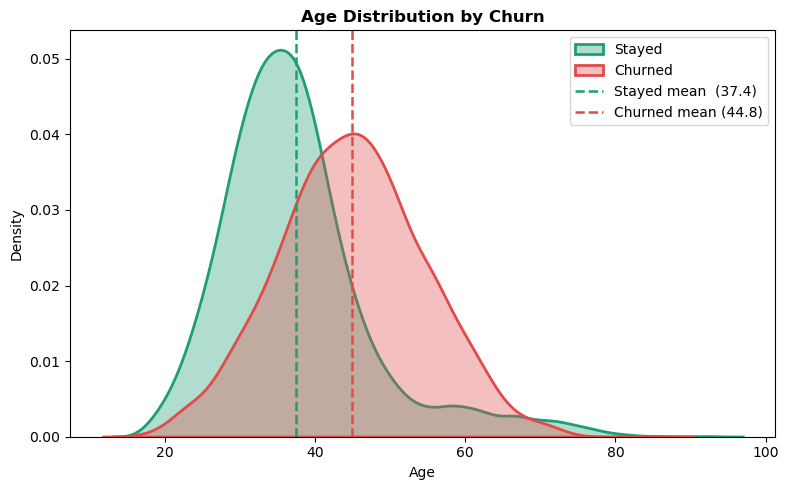

In [35]:
#we have used this figure to churn effects on age and it is clearly seen
#that after the age of 40, customers are leaving the bank and it is peaking at 
#age of 45-55.
plt.figure(figsize=(8, 5))

for churn_val, label, color in zip([0, 1],
                                    ['Stayed', 'Churned'],
                                    ['#1D9E75', '#E24B4A']):
    sns.kdeplot(data[data['churn'] == churn_val]['age'],
                label=label, color=color,
                fill=True, alpha=0.35, linewidth=2)

# Mean lines to highlight the gap
stayed_mean  = data[data['churn'] == 0]['age'].mean()
churned_mean = data[data['churn'] == 1]['age'].mean()

plt.axvline(stayed_mean,  color='#1D9E75', linestyle='--',
            linewidth=1.8, label=f'Stayed mean  ({stayed_mean:.1f})')
plt.axvline(churned_mean, color='#E24B4A', linestyle='--',
            linewidth=1.8, label=f'Churned mean ({churned_mean:.1f})')

plt.title('Age Distribution by Churn', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

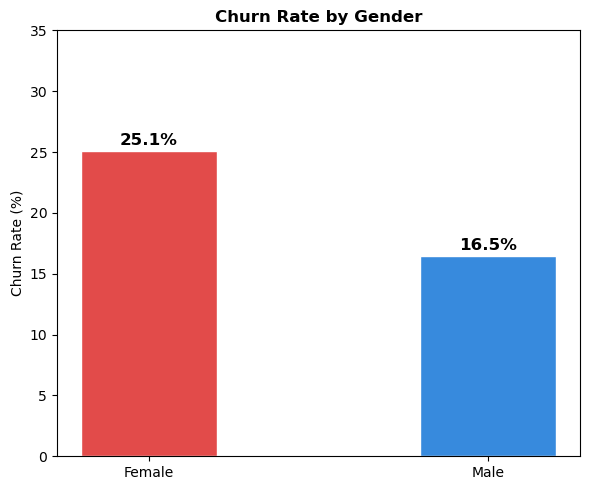

In [38]:
#"Sir, I grouped the data by gender and calculated churn rate for each group. 
#Females churn at 25% and males at 16.5% — that's a significant difference of nearly 9%.
gender_churn = data.groupby('gender')['churn'].mean() * 100

plt.figure(figsize=(6, 5))

bars = plt.bar(
    gender_churn.index,
    gender_churn.values,
    color=['#E24B4A', '#378ADD'],
    edgecolor='white',
    width=0.4
)

# Adding percentage on top of each bar
for bar, val in zip(bars, gender_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

plt.title('Churn Rate by Gender', fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 35)
plt.tight_layout()
plt.show()

   country  gender  churn_rate
0   France  Female   20.344980
1   France    Male   12.713404
2  Germany  Female   37.552389
3  Germany    Male   27.811550
4    Spain  Female   21.212121
5    Spain    Male   13.112392


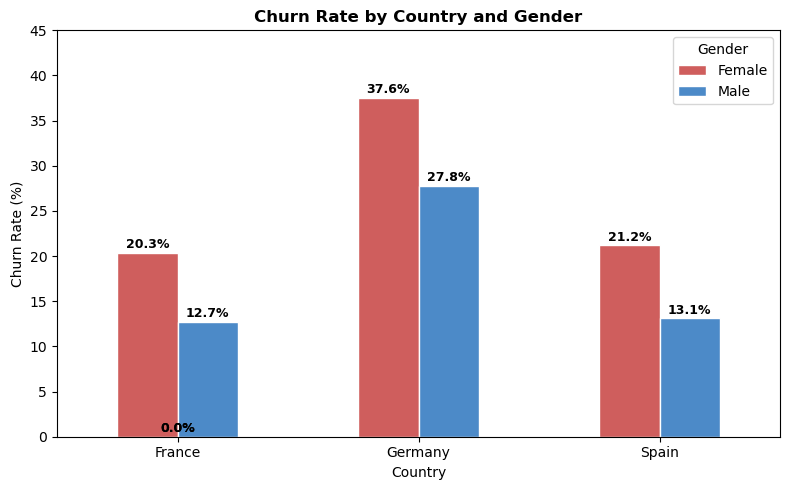

In [39]:
#In all three countries, females are more churned than male customers.
# ── Gender + Country vs Churn ────────────────────────────────────────────
# Question: which gender in which country churns the most?
# We group by both gender AND country together to find the answer
gender_country_churn = (
    data.groupby(['country', 'gender'])['churn']
    .mean() * 100
).reset_index()

gender_country_churn.columns = ['country', 'gender', 'churn_rate']
print(gender_country_churn)

plt.figure(figsize=(8, 5))

sns.barplot(data=gender_country_churn,
            x='country', y='churn_rate', hue='gender',
            palette={'Female': '#E24B4A', 'Male': '#378ADD'},
            edgecolor='white', width=0.5)

# Adding percentage labels on each bar
for bar in plt.gca().patches:
    plt.gca().text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=9, fontweight='bold'
    )

plt.title('Churn Rate by Country and Gender', fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Country')
plt.ylim(0, 45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

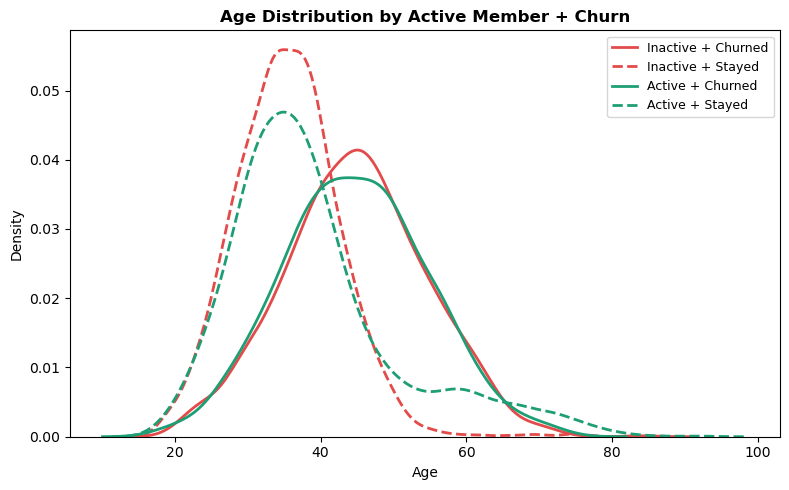

In [40]:
#Inactive customers above age 40 are the single riskiest segment — 
#combining age and active_member together reveals a pattern neither column could show alone."

# ── Age + Active Member vs Churn ─────────────────────────────────────────
# Question: Are inactive older customers the highest risk group?
# We split age distribution by active_member status and churn together
# active_member = 0 → inactive, active_member = 1 → active

# Adding readable labels for active_member column
data['member_status'] = data['active_member'].map({0: 'Inactive', 1: 'Active'})

plt.figure(figsize=(8, 5))

# Plotting age KDE for all 4 combinations:
# Inactive + Churned, Inactive + Stayed, Active + Churned, Active + Stayed
colors   = {'Inactive': '#E24B4A', 'Active': '#1D9E75'}
styles   = {1: '-', 0: '--'}       # churned = solid, stayed = dashed

for active_val, active_label in [(0, 'Inactive'), (1, 'Active')]:
    for churn_val, churn_label in [(1, 'Churned'), (0, 'Stayed')]:
        subset = data[
            (data['active_member'] == active_val) &
            (data['churn'] == churn_val)
        ]['age']

        sns.kdeplot(subset,
                    label=f'{active_label} + {churn_label}',
                    color=colors[active_label],
                    linestyle=styles[churn_val],
                    linewidth=2, fill=False)

plt.title('Age Distribution by Active Member + Churn', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

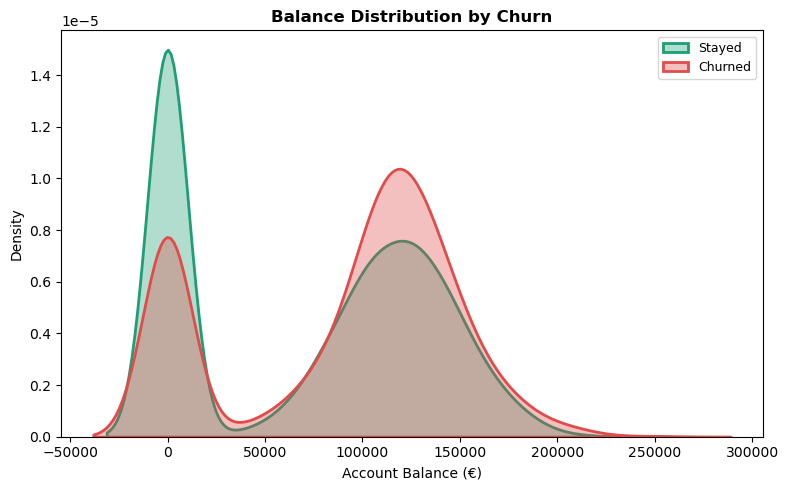

In [46]:
#There is a big spike at 0 for stayed customers — meaning many stayed customers have zero balance. 
#Churned customers have a higher average balance of €91,108 vs €72,745 for stayed. 
#This is a counter-intuitive finding — the bank is actually losing its wealthier customers more

plt.figure(figsize=(8, 5))
for churn_val, label, color in zip([0, 1],
                                    ['Stayed', 'Churned'],
                                    ['#1D9E75', '#E24B4A']):
    sns.kdeplot(data[data['churn'] == churn_val]['balance'],
                label=label, color=color,
                fill=True, alpha=0.35, linewidth=2)
plt.title('Balance Distribution by Churn', fontweight='bold')
plt.xlabel('Account Balance (€)')
plt.ylabel('Density')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()



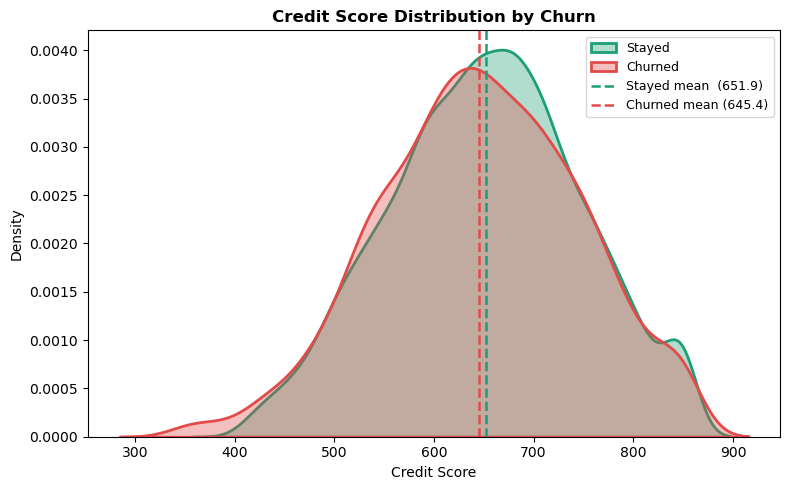

In [49]:
#Sir, I plotted the credit score distribution for churned and stayed customers. 
#The two curves are almost completely overlapping — meaning customers who left and customers who stayed have almost the same credit scores.
#The average difference is only 6 points (645 vs 651) on a scale of 300 to 850, which is practically nothing.
#This tells us that credit score alone cannot help us predict whether a customer will churn or not. 
#It is a weak signal — we keep it in the data but we don't rely on it heavily."

plt.figure(figsize=(8, 5))

for churn_val, label, color in zip([0, 1],
                                    ['Stayed', 'Churned'],
                                    ['#1D9E75', '#E24B4A']):
    sns.kdeplot(data[data['churn'] == churn_val]['credit_score'],
                label=label, color=color,
                fill=True, alpha=0.35, linewidth=2)

# Mean lines to highlight the small gap
stayed_mean  = data[data['churn'] == 0]['credit_score'].mean()
churned_mean = data[data['churn'] == 1]['credit_score'].mean()

plt.axvline(stayed_mean,  color='#1D9E75', linestyle='--',
            linewidth=1.8, label=f'Stayed mean  ({stayed_mean:.1f})')
plt.axvline(churned_mean, color='#E24B4A', linestyle='--',
            linewidth=1.8, label=f'Churned mean ({churned_mean:.1f})')

plt.title('Credit Score Distribution by Churn', fontweight='bold')
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [52]:
data.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'active_member', 'churn', 'member_status'],
      dtype='object')

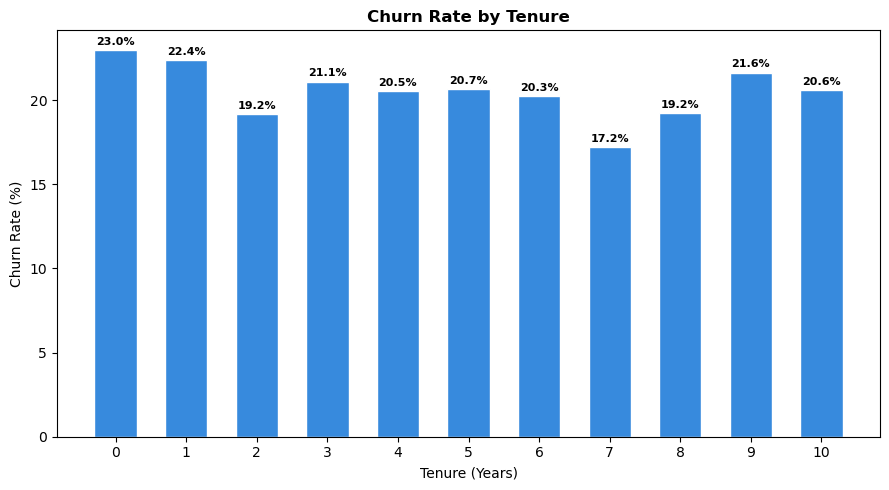

In [53]:
#All bars will be at almost the same height — around 20% across all tenure values. 
#There is no clear up or down trend. A customer who has been with the bank 
#for 1 year churns at almost the same rate as someone who has been there for 9 years.
# ── Tenure vs Churn ──────────────────────────────────────────────────────
# Question: Do customers who stay longer churn less?
# tenure = number of years with the bank (0 to 10)
# p-value = 0.161 → weak contributor, pattern may not be real
# We use bar chart because tenure has only 11 unique values (0-10)

tenure_churn = data.groupby('tenure')['churn'].mean() * 100

plt.figure(figsize=(9, 5))

bars = plt.bar(
    tenure_churn.index,
    tenure_churn.values,
    color='#378ADD',
    edgecolor='white',
    width=0.6
)

# Adding percentage on top of each bar
for bar, val in zip(bars, tenure_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontsize=8, fontweight='bold'
    )

plt.title('Churn Rate by Tenure', fontweight='bold')
plt.xlabel('Tenure (Years)')
plt.ylabel('Churn Rate (%)')
plt.xticks(tenure_churn.index)   # show all years 0-10 on x axis
plt.tight_layout()
plt.show()

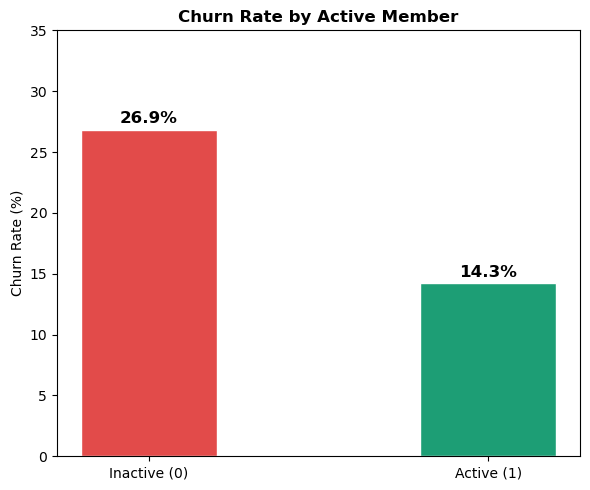

In [54]:
#Inactive customers churn at 26.9% vs active customers at 14.3% — 
#that's almost double the rate.


# ── Active Member vs Churn ───────────────────────────────────────────────
# Question: Do inactive customers churn more than active ones?
# active_member = 0 → inactive, active_member = 1 → active
# p-value < 0.001 → very strong contributor

active_churn = data.groupby('active_member')['churn'].mean() * 100

plt.figure(figsize=(6, 5))

bars = plt.bar(
    ['Inactive (0)', 'Active (1)'],
    active_churn.values,
    color=['#E24B4A', '#1D9E75'],
    edgecolor='white',
    width=0.4
)

# Adding percentage on top of each bar
for bar, val in zip(bars, active_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

plt.title('Churn Rate by Active Member', fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 35)
plt.tight_layout()
plt.show()

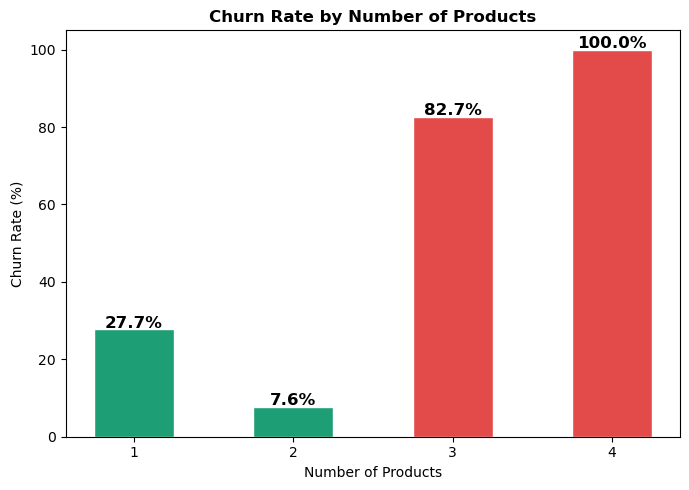

In [56]:
#1 and 2 products → churn rate is low (green bars). 3 and 4 products 
#→ churn rate explodes dramatically (red bars). This is a very surprising and counter-intuitive finding.

# ── Products Number vs Churn ─────────────────────────────────────────────
# Question: Do customers with more products churn more or less?


product_churn = data.groupby('products_number')['churn'].mean() * 100

plt.figure(figsize=(7, 5))

bars = plt.bar(
    product_churn.index.astype(str),
    product_churn.values,
    color=['#1D9E75', '#1D9E75', '#E24B4A', '#E24B4A'],
    edgecolor='white',
    width=0.5
)

# Adding percentage on top of each bar
for bar, val in zip(bars, product_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

plt.title('Churn Rate by Number of Products', fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()


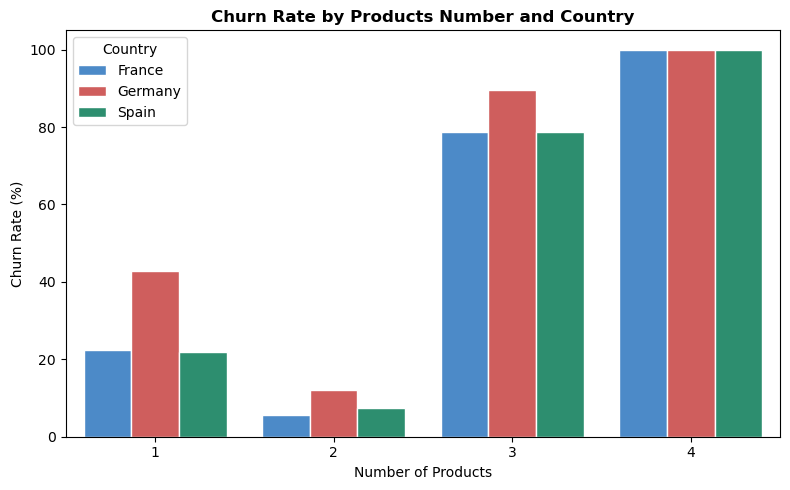

In [57]:
#Customers with 3 or 4 products churn at an extremely high rate across all countries — 
# This is surprising because you'd expect more products to mean more loyalty. 
#Germany consistently shows higher churn across all product counts compared to France and Spain.
product_country_churn = (
    data.groupby(['country', 'products_number'])['churn']
    .mean() * 100
).reset_index()

product_country_churn.columns = ['country', 'products_number', 'churn_rate']

plt.figure(figsize=(8, 5))

sns.barplot(data=product_country_churn,
            x='products_number', y='churn_rate', hue='country',
            palette={'France' : '#378ADD',
                     'Germany': '#E24B4A',
                     'Spain'  : '#1D9E75'},
            edgecolor='white')

plt.title('Churn Rate by Products Number and Country', fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

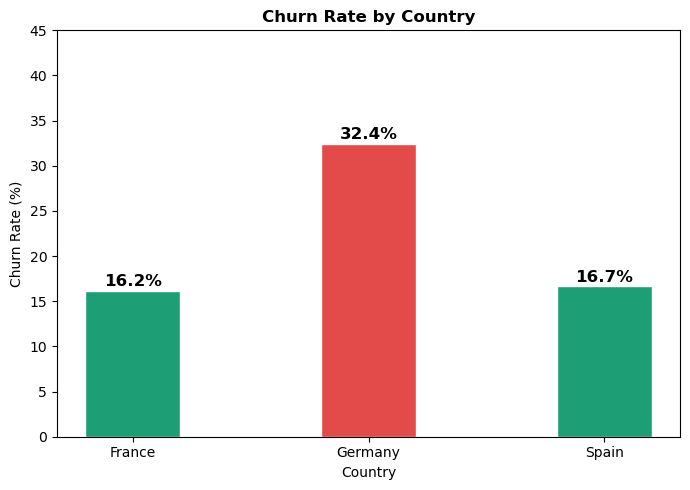

In [58]:
# Germany has significantly higher churn than France and Spain

# ── Country vs Churn ─────────────────────────────────────────────────────
# Question: Does the country a customer belongs to affect churn?
# Germany has significantly higher churn than France and Spain
country_churn = data.groupby('country')['churn'].mean() * 100
plt.figure(figsize=(7, 5))
bars = plt.bar(
    country_churn.index,
    country_churn.values,
    color=['#1D9E75', '#E24B4A', '#1D9E75'],  # Germany red, others green
    edgecolor='white',
    width=0.4
)

# Adding percentage on top of each bar
for bar, val in zip(bars, country_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )

plt.title('Churn Rate by Country', fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 45)
plt.tight_layout()
plt.show()